# Isogrid Module Calculator
Supports both regular isogrid and open web calculations.
Does not optimize

### Definitions from Handbook for translating equations
t = thickness of Skin  
b = width of rib web  
d = depth of web  
c = depth of flange  
w = width of flange  
s = t+d = plate thickness of unflanged isogrid  
h = height of triangle  
a = leg of triangle (center to center of nodes)  
kc = column fixity

beta = b/a  (width of rib web/leg of triangle)  


Module Design Parameters:
    Inner Diameter: 6.0625 in
    Skin Thickness: 0.1 in
    Rib Depth: 0.1 in
    Rib Width: 0.1 in
    Number of radial divisions: 18
Module Properties:
    Tbar 0.127
    General Instability - 514.7 lbf/in  10127 lbf
    Skin Buckling       - 2500.5 lbf/in  49195 lbf
    Rib Cripling        - 18040.7 lbf/in 354937 lbf
Rel Weight: 4.98
Rel Strength:  1.3

Module Design Parameters:
    Inner Diameter: 6.0625 in
    Skin Thickness: 0.1 in
    Rib Depth: 0.1 in
    Rib Width: 0.05 in
    Number of radial divisions: 18
Module Properties:
    Tbar 0.114
    General Instability - 436.0 lbf/in   8578 lbf
    Skin Buckling       - 2395.7 lbf/in  47133 lbf
    Rib Cripling        - 4321.2 lbf/in  85015 lbf
Rel Weight: 4.44
Rel Strength:  1.1

Module Design Parameters:
    Inner Diameter: 6.0625 in
    Skin Thickness: 0.08 in
    Rib Depth: 0.1 in
    Rib Width: 0.05 in
    Number of radial divisions: 18
Module Properties:
    Tbar 0.094
    General Instability - 309

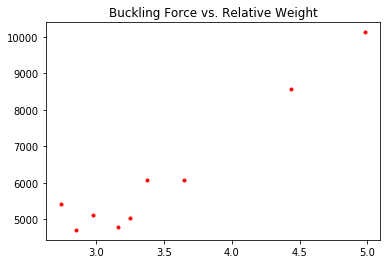

In [9]:
import math
import matplotlib.pyplot as plt

# Material properties 
E = 1.85 # Young's Modules, GPa for Formlabs Nylon 12
E_imp = E*145038 # PSI
nu = 0.33 # Poisson's Ratio for Al 6061-T6
material_name = 'Nylon12'
#F_ty = 40 # ksi (Yield Strength)
F_tu = 7.25 # ksi (Ultimate Strength) 50 MPa for Formlabs Nylon 12

# Instability Coefs
c0 = 0.397    # 4.2.005
c1 = 10.2     # 4.2.006
c2 = 0.616    # 4.2.008

kc = 2.0 # assumed on page 4.9.009

# Common Properties
flanges = False

# Parametric Space
# Inner Diameter, wall_t, rib_depth, rib_width, num_cells, Name
module_options = [[6.0625,0.1,0.1,0.1,18, 'Initial'],
                  [6.0625,0.1,0.1,0.05,18, 'Thinner Ribs'],
                  [6.0625,0.08,0.1,0.05,18, 'Thinner Skin'],
                  [6.0625,0.07,0.1,0.05,18, 'Thinner Skin2'],
                  [6.0625,0.07,0.1,0.05,15, 'Less Cells'],
                  [6.0625,0.07,0.14,0.05,15, 'Taller Ribs'],
                  [6.0625,0.06,0.14,0.05,15, 'Thinner Skin3'],
                  [6.0625,0.06,0.14,0.04,15, 'Narrower Ribs'],
                  [6.0625,0.055,0.192,0.032,15, 'Taller Ribs2']]
results = []
for module in module_options:
    print() # new line
    module_id = module[0]
    skin_t = module[1]
    rib_depth = module[2]
    rib_width = module[3]
    num_radial_divisions = module[4]
    module_od = module_id+2*rib_depth
    module_r = module_od/2
    rel_weight_data = []
    pattern_size = module_od*math.pi/num_radial_divisions
    cell_height = pattern_size
    a = 2*cell_height/(3**0.5)

    print('Module Design Parameters:')
    print(f'    Inner Diameter: {module[0]} in')
    print(f'    Skin Thickness: {module[1]} in')
    print(f'    Rib Depth: {module[2]} in')
    print(f'    Rib Width: {module[3]} in')
    print(f'    Number of radial divisions: {module[4]}')

    print('Module Properties:')
    if skin_t == 0.0:
        # Open Web
        # Check that rib depth > rib_width (d>b)
        if rib_depth > rib_width:
            print('    PASS - Rib shape acceptable (depth > width)')
        else:
            print('    FAIL - Rib depth needs to be greater than rib width')
        E_bar = E_imp*rib_width/a
        t_bar = 3*rib_width*rib_depth/cell_height
        beta = rib_width/a
        N_cr_1 = 0.612*c0*E_imp*(rib_width*rib_depth*rib_depth)/(module_r*cell_height) # Eqn 4.9.8 (Rectangular Stiffeners)
        N_cr_2 = 1.422*kc*E_imp*rib_depth*(beta**3) # Eqn 4.9.10
        
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2)
    
        print(f'    Tbar {t_bar:.3f}')
        print(f'    Beta {beta:.3f}')
        print(f'    E_star {E_bar:.3e}')
        print('    General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('    Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
    else:
        # Closed Web
        alpha = (rib_width*rib_depth)/(skin_t*cell_height) # Web non-dimensional ratio, pg. 2.0.008
        delta = rib_depth/skin_t # rib depth to skin thickness ratio, pg. 2.0.008
        if flanges == False:
            beta = (3*alpha*(1+delta)**2+(1+alpha)*(1+alpha*delta**2))**0.5
            t_star = skin_t*beta/(1+alpha) # equivilent thickness, Eq. 2.5.3
            t_bar = skin_t*(1+3*alpha)
            E_star = E*(1+alpha)**2.0/beta # equivilent Young's Modulus Eq. 2.5.4#
        N_cr_1 = c0*E_imp*skin_t*skin_t/module_r*beta
        N_cr_2 = c1*E_imp*skin_t*(1+alpha)*(skin_t*skin_t)/(pattern_size*pattern_size)
        N_cr_3 = c2*E_imp*skin_t*(1+alpha)*(rib_width*rib_width)/(rib_depth*rib_depth)
    
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        F_cr_3 = N_cr_3*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2,F_cr_3)
    
        print(f'    Tbar {t_bar:.3f}')
        print('    General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('    Skin Buckling       - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
        print('    Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_3,F_cr_3))
            
    cs_area = t_bar*2*math.pi*(module_r+t_bar/2)
    if skin_t == 0.0:
        # Note: We add the weight of skin to the weight
        cs_area = (t_bar+0.016)*2*math.pi*(module_r+t_bar/2)
    rel_w = cs_area/0.513412
    print('Rel Weight: {:4.3}'.format(rel_w))
    print('Rel Strength: {:4.3}'.format(strength/7783))
    rel_weight_data.append(rel_w)
    results.append([module_id, rel_w, strength])

# Buckling
buckling_plot = plt.figure(1)
plt.title('Buckling Force vs. Relative Weight')
for item in results:
    plt.plot(item[1], item[2], 'r.', label='id_'+str(item[0]))
#plt.legend()

